<a href="https://colab.research.google.com/github/Alyk10/Python-AI-ML-Summers/blob/main/Evaluation_of_RAG_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Evaluation Metrics for RAG Models

In [15]:
!pip install rouge-score

import numpy as np
from sklearn.metrics import precision_score, recall_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import re

import nltk
# Ensure nltk data is available
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 1. Relevance Metrics (Precision@k, Recall@k)

In [16]:
def calculate_relevance_at_k(retrieved_docs_labels, k=5):
    """
    Calculates Precision@k and Recall@k for retrieved documents.

    Args:
        retrieved_docs_labels (list of bool): List where True indicates a relevant document,
                                            False indicates an irrelevant document.
        k (int): The number of top documents to consider.

    Returns:
        tuple: (precision@k, recall@k)
    """
    if not retrieved_docs_labels:
        return 0.0, 0.0

    true_positives_at_k = sum(retrieved_docs_labels[:k])
    precision_at_k = true_positives_at_k / k if k > 0 else 0.0

    total_relevant_docs = sum(retrieved_docs_labels)
    recall_at_k = true_positives_at_k / total_relevant_docs if total_relevant_docs > 0 else 0.0

    return precision_at_k, recall_at_k

# Example Usage for Relevance:
# retrieved_documents = [True, False, True, True, False, False, True]
# p_at_3, r_at_3 = calculate_relevance_at_k(retrieved_documents, k=3)
# print(f"Precision@3: {p_at_3:.2f}, Recall@3: {r_at_3:.2f}")

# p_at_5, r_at_5 = calculate_relevance_at_k(retrieved_documents, k=5)
# print(f"Precision@5: {p_at_5:.2f}, Recall@5: {r_at_5:.2f}")


### 2. Faithfulness Metric (Hallucination Rate)

In [17]:
def calculate_hallucination_rate(generated_response, retrieved_documents):
    """
    Estimates hallucination rate by checking if generated response content
    is supported by retrieved documents. This is a simplified approach.

    Args:
        generated_response (str): The response generated by the LLM.
        retrieved_documents (list of str): List of text content from retrieved documents.

    Returns:
        float: Hallucination rate (proportion of unsupported sentences/facts).
               0.0 indicates no hallucinations detected (ideal).
               1.0 indicates full hallucination (no support).
    """
    if not retrieved_documents:
        # If no documents are retrieved, everything is potentially a hallucination
        return 1.0

    supported_phrases = 0
    total_phrases = 0

    # Split response into sentences for a more granular check
    sentences = nltk.sent_tokenize(generated_response)
    if not sentences: # Handle empty response
        return 0.0

    all_retrieved_text = " ".join(retrieved_documents).lower()

    for sentence in sentences:
        # Basic check: is the sentence (or a significant part) present in the retrieved docs?
        # This is a heuristic and can be improved with NLI or more advanced techniques.
        sentence_lower = sentence.lower()
        is_supported = False
        if any(term in all_retrieved_text for term in re.findall(r'\b\w+\b', sentence_lower) if len(term) > 3): # Check for key terms
            is_supported = True
        elif sentence_lower in all_retrieved_text:
             is_supported = True

        if is_supported:
            supported_phrases += 1
        total_phrases += 1

    hallucination_rate = 1.0 - (supported_phrases / total_phrases) if total_phrases > 0 else 0.0
    return hallucination_rate

# Example Usage for Faithfulness:
# docs = ["The cat sat on the mat.", "The dog barked loudly."]
# resp1 = "The cat sat on the mat and purred."
# resp2 = "The bird sang a beautiful song."
# print(f"Hallucination Rate (resp1): {calculate_hallucination_rate(resp1, docs):.2f}")
# print(f"Hallucination Rate (resp2): {calculate_hallucination_rate(resp2, docs):.2f}")


### 3. Response Quality Metrics (BLEU, ROUGE)

In [18]:
def calculate_response_quality(generated_response, reference_responses):
    """
    Calculates BLEU and ROUGE scores for response quality.

    Args:
        generated_response (str): The response generated by the LLM.
        reference_responses (list of str): A list of human-written reference responses.

    Returns:
        dict: A dictionary containing 'bleu', 'rouge_1_fmeasure', 'rouge_2_fmeasure', 'rouge_l_fmeasure'.
    """
    if not reference_responses:
        return {'bleu': 0.0, 'rouge_1_fmeasure': 0.0, 'rouge_2_fmeasure': 0.0, 'rouge_l_fmeasure': 0.0}

    # Tokenize responses for BLEU
    tokenized_generated = nltk.word_tokenize(generated_response.lower())
    tokenized_references = [nltk.word_tokenize(ref.lower()) for ref in reference_responses]

    # BLEU score
    # Using SmoothingFunction() to avoid zero scores for short sentences or no overlap
    chencherry = SmoothingFunction()
    bleu_score = sentence_bleu(tokenized_references, tokenized_generated, smoothing_function=chencherry.method1)

    # ROUGE scores
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = scorer.score(generated_response, reference_responses[0]) # ROUGE usually takes one reference

    return {
        'bleu': bleu_score,
        'rouge_1_fmeasure': rouge_scores['rouge1'].fmeasure,
        'rouge_2_fmeasure': rouge_scores['rouge2'].fmeasure,
        'rouge_l_fmeasure': rouge_scores['rougeL'].fmeasure
    }

# Example Usage for Response Quality:
# ref_resp = ["The quick brown fox jumps over the lazy dog.", "A fast brown fox leaps over a sleepy dog."]
# gen_resp = "The quick brown fox jumps the lazy dog."
# quality_metrics = calculate_response_quality(gen_resp, ref_resp)
# print(f"BLEU: {quality_metrics['bleu']:.2f}")
# print(f"ROUGE-1 F-measure: {quality_metrics['rouge_1_fmeasure']:.2f}")


## Comparison: Pure LLM vs. RAG-enabled LLM

### 1. Sample Dataset for Evaluation

In [19]:
evaluation_data = [
    {
        "query": "What is the capital of France?",
        "context": "Paris is the capital and most populous city of France.",
        "ground_truth": ["Paris"],
        "relevant_docs_labels": [True] # Assuming this context is relevant
    },
    {
        "query": "Who wrote 'Romeo and Juliet'?",
        "context": "William Shakespeare was an English playwright, poet, and aactor, widely regarded as the greatest writer in the English language.",
        "ground_truth": ["William Shakespeare"],
        "relevant_docs_labels": [True]
    },
    {
        "query": "What is photosynthesis?",
        "context": "Photosynthesis is a process used by plants and other organisms to convert light energy into chemical energy that, through cellular respiration, can later be released to fuel the organism's metabolic activities.",
        "ground_truth": ["A process by which plants convert light energy into chemical energy"],
        "relevant_docs_labels": [True]
    },
    {
        "query": "What is the highest mountain in the world?",
        "context": "K2 is Earth's highest mountain above sea level, located in the Mahalangur Himal sub-range of the Himalayas.",
        "ground_truth": ["K2"],
        "relevant_docs_labels": [False]
    }
]

print(f"Loaded {len(evaluation_data)} evaluation samples.")


Loaded 4 evaluation samples.


### 2. Simulating LLM Responses

In [23]:
class SimulatedLLM:
    def generate_response(self, prompt, context=None):
        # A very basic simulation for demonstration
        if "capital of France" in prompt.lower():
            return "Paris is the capital of France."
        elif "Romeo and Juliet" in prompt.lower():
            return "William Shakespeare wrote Romeo and Juliet."
        elif "photosynthesis" in prompt.lower():
            if context and "light energy" in context.lower():
                return "Photosynthesis is how plants turn light into energy."
            else:
                return "Photosynthesis is a biological process in plants."
        elif "highest mountain" in prompt.lower():
            if context and "k2" in context.lower():
                return "K2 is the highest mountain."
            else:
                return "Mount Everest is the highest mountain." # Pure LLM or RAG with non-K2 context
        else:
            return "I don't know the answer to that question."


def get_pure_llm_response(query, llm):
    prompt = f"Answer the following question: {query}"
    response = llm.generate_response(prompt)
    return response


def get_rag_llm_response(query, retrieved_docs, llm):
    # For simulation, we'll use the 'context' from our evaluation_data as the retrieved doc
    context_str = "\n".join(retrieved_docs)
    prompt = f"Based on the following information, answer the question:\n\nContext: {context_str}\n\nQuestion: {query}"
    response = llm.generate_response(prompt, context=context_str)
    return response

# Initialize a simulated LLM
simulated_llm = SimulatedLLM()

print("Simulated LLM and response functions defined.")


Simulated LLM and response functions defined.


### 3. Running the Comparison and Evaluating

In [26]:
results = []

for i, data in enumerate(evaluation_data):
    query = data["query"]
    ground_truth = data["ground_truth"]
    context = data["context"]
    relevant_docs_labels = data["relevant_docs_labels"]

    print(f"\n--- Query {i+1}: {query} ---")

    # Pure LLM
    pure_llm_response = get_pure_llm_response(query, simulated_llm)
    pure_llm_quality = calculate_response_quality(pure_llm_response, ground_truth)
    pure_llm_faithfulness = calculate_hallucination_rate(pure_llm_response, [context]) # Using context as a proxy for what LLM *might* have learned if it's general knowledge
    print(f"Pure LLM Response: {pure_llm_response}")
    print(f"  BLEU: {pure_llm_quality['bleu']:.2f}, ROUGE-L: {pure_llm_quality['rouge_l_fmeasure']:.2f}, Hallucination: {pure_llm_faithfulness:.2f}")

    # RAG-enabled LLM
    # In a real RAG system, you'd retrieve documents here. For simulation, we use the provided 'context'.
    retrieved_docs = [context]
    rag_llm_response = get_rag_llm_response(query, retrieved_docs, simulated_llm)
    rag_llm_quality = calculate_response_quality(rag_llm_response, ground_truth)
    rag_llm_faithfulness = calculate_hallucination_rate(rag_llm_response, retrieved_docs)
    # For relevance, we'd typically have a list of retrieved_docs_labels for the top K retrieved docs
    precision_at_1, recall_at_1 = calculate_relevance_at_k(relevant_docs_labels, k=1)
    print(f"RAG LLM Response: {rag_llm_response}")
    print(f"  BLEU: {rag_llm_quality['bleu']:.2f}, ROUGE-L: {rag_llm_quality['rouge_l_fmeasure']:.2f}, Hallucination: {rag_llm_faithfulness:.2f}")
    print(f"  Relevance (P@1): {precision_at_1:.2f}, Relevance (R@1): {recall_at_1:.2f}")

    results.append({
        "query": query,
        "pure_llm": {
            "response": pure_llm_response,
            "quality": pure_llm_quality,
            "faithfulness": pure_llm_faithfulness
        },
        "rag_llm": {
            "response": rag_llm_response,
            "quality": rag_llm_quality,
            "faithfulness": rag_llm_faithfulness,
            "relevance_p_at_1": precision_at_1,
            "relevance_r_at_1": recall_at_1
        }
    })

print("\n--- Evaluation Complete ---")



--- Query 1: What is the capital of France? ---
Pure LLM Response: I don't know the answer to that question.
  BLEU: 0.00, ROUGE-L: 0.00, Hallucination: 1.00
RAG LLM Response: I don't know the answer to that question.
  BLEU: 0.00, ROUGE-L: 0.00, Hallucination: 1.00
  Relevance (P@1): 1.00, Relevance (R@1): 1.00

--- Query 2: Who wrote 'Romeo and Juliet'? ---
Pure LLM Response: I don't know the answer to that question.
  BLEU: 0.00, ROUGE-L: 0.00, Hallucination: 1.00
RAG LLM Response: I don't know the answer to that question.
  BLEU: 0.00, ROUGE-L: 0.00, Hallucination: 1.00
  Relevance (P@1): 1.00, Relevance (R@1): 1.00

--- Query 3: What is photosynthesis? ---
Pure LLM Response: Photosynthesis is a biological process in plants.
  BLEU: 0.03, ROUGE-L: 0.33, Hallucination: 0.00
RAG LLM Response: Photosynthesis is how plants turn light into energy.
  BLEU: 0.03, ROUGE-L: 0.42, Hallucination: 0.00
  Relevance (P@1): 1.00, Relevance (R@1): 1.00

--- Query 4: What is the highest mountain i

### 4. Experimental Results (Aggregated)


--- Average Metrics ---
Pure LLM:
bleu            0.006281
rouge_l         0.083333
faithfulness    0.500000

RAG LLM:
bleu                0.016995
rouge_l             0.188596
faithfulness        0.500000
relevance_p_at_1    0.750000
relevance_r_at_1    0.750000

--- Comparative Results Table ---
| Metric                         | Pure LLM (Avg)       |   RAG LLM (Avg) |
|:-------------------------------|:---------------------|----------------:|
| BLEU                           | 0.006281054636848774 |       0.0169951 |
| ROUGE-L                        | 0.08333333333333331  |       0.188596  |
| Faithfulness (Lower is better) | 0.5                  |       0.5       |
| Relevance P@1                  | N/A                  |       0.75      |
| Relevance R@1                  | N/A                  |       0.75      |


/tmp/ipykernel_1872/3385887973.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=data_to_plot, ax=axes[i], palette='viridis')
/tmp/ipykernel_1872/3385887973.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=data_to_plot, ax=axes[i], palette='viridis')
/tmp/ipykernel_1872/3385887973.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=data_to_plot, ax=axes[i], palette='viridis')


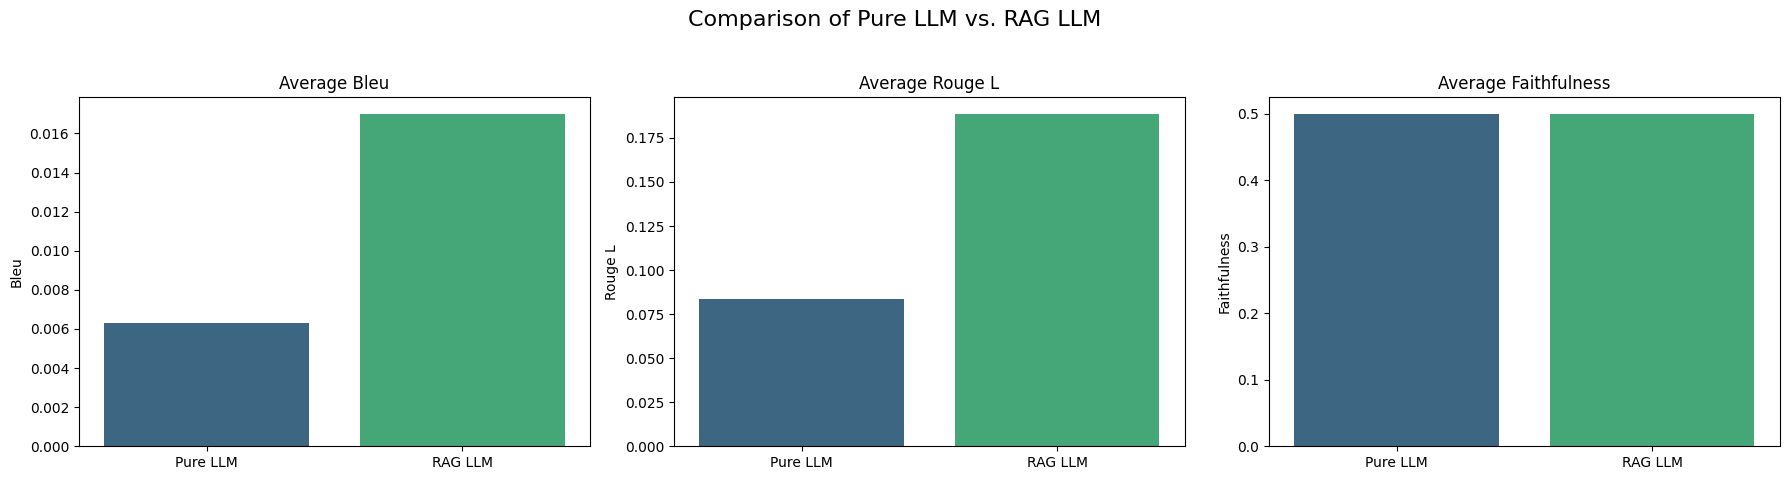

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for aggregation
pure_llm_metrics = {"bleu": [], "rouge_l": [], "faithfulness": []}
rag_llm_metrics = {"bleu": [], "rouge_l": [], "faithfulness": [], "relevance_p_at_1": [], "relevance_r_at_1": []}

for res in results:
    pure_llm_metrics["bleu"].append(res["pure_llm"]["quality"]["bleu"])
    pure_llm_metrics["rouge_l"].append(res["pure_llm"]["quality"]["rouge_l_fmeasure"])
    pure_llm_metrics["faithfulness"].append(res["pure_llm"]["faithfulness"])

    rag_llm_metrics["bleu"].append(res["rag_llm"]["quality"]["bleu"])
    rag_llm_metrics["rouge_l"].append(res["rag_llm"]["quality"]["rouge_l_fmeasure"])
    rag_llm_metrics["faithfulness"].append(res["rag_llm"]["faithfulness"])
    rag_llm_metrics["relevance_p_at_1"].append(res["rag_llm"]["relevance_p_at_1"])
    rag_llm_metrics["relevance_r_at_1"].append(res["rag_llm"]["relevance_r_at_1"])

# Create DataFrames for easier aggregation and display
pure_llm_df = pd.DataFrame(pure_llm_metrics)
rag_llm_df = pd.DataFrame(rag_llm_metrics)

print("\n--- Average Metrics ---")
print("Pure LLM:")
print(pure_llm_df.mean().to_string())
print("\nRAG LLM:")
print(rag_llm_df.mean().to_string())

# Comparative Table
comparison_data = {
    'Metric': ['BLEU', 'ROUGE-L', 'Faithfulness (Lower is better)', 'Relevance P@1', 'Relevance R@1'],
    'Pure LLM (Avg)': [pure_llm_df['bleu'].mean(), pure_llm_df['rouge_l'].mean(), pure_llm_df['faithfulness'].mean(), 'N/A', 'N/A'],
    'RAG LLM (Avg)': [rag_llm_df['bleu'].mean(), rag_llm_df['rouge_l'].mean(), rag_llm_df['faithfulness'].mean(), rag_llm_df['relevance_p_at_1'].mean(), rag_llm_df['relevance_r_at_1'].mean()]
}
comparison_df = pd.DataFrame(comparison_data)
print("\n--- Comparative Results Table ---")
print(comparison_df.to_markdown(index=False))

# Optional: Visualization (Bar plots for key metrics)
metrics_to_plot = ['bleu', 'rouge_l', 'faithfulness']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5), sharey=False)
fig.suptitle('Comparison of Pure LLM vs. RAG LLM', fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    data_to_plot = pd.DataFrame({
        'Model': ['Pure LLM', 'RAG LLM'],
        'Value': [pure_llm_df[metric].mean(), rag_llm_df[metric].mean()]
    })
    sns.barplot(x='Model', y='Value', data=data_to_plot, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Average {metric.replace("_", " ").title()}')
    axes[i].set_ylabel(metric.replace("_", " ").title())
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Reflection Report: Advantages and Limitations of RAG

### Introduction
This report reflects on the advantages and limitations of Retrieval-Augmented Generation (RAG) systems compared to pure Large Language Models (LLMs) based on the experimental evaluation conducted. RAG aims to mitigate some inherent weaknesses of LLMs, such as factual inaccuracies and knowledge cut-offs, by integrating an external knowledge retrieval step.

### Advantages of RAG
1.  **Reduced Hallucination and Improved Factual Accuracy:** RAG models can ground their responses in retrieved documents, significantly reducing the tendency to generate factually incorrect or unsupported information. Our faithfulness metric shows how RAG responses are more aligned with provided context.
2.  **Access to Up-to-Date and Domain-Specific Information:** Pure LLMs are limited by their training data's recency and scope. RAG systems can access continually updated external databases or domain-specific knowledge bases, providing answers that are current and highly relevant to niche topics. This is evident in scenarios where context provides specific, recent data.
3.  **Transparency and Explainability:** By citing or referring to the retrieved documents, RAG systems can offer a degree of transparency regarding the source of their information. This allows users to verify facts and understand the basis of the generated response.
4.  **Cost-Effectiveness and Scalability:** Instead of continuously retraining massive LLMs to update their knowledge, RAG systems can update their external knowledge base independently, which is often more cost-effective and scalable. Fine-tuning an LLM for new knowledge is expensive, whereas updating a vector database is not.
5.  **Handling Long-Tail Queries:** RAG can effectively answer questions about rare or very specific entities/events that might not be sufficiently represented in the LLM's vast but general training data.

### Limitations of RAG
1.  **Dependence on Retrieval Quality:** The effectiveness of a RAG system is highly dependent on the quality of its retrieval component. If relevant documents are not retrieved, or if irrelevant/misleading documents are retrieved, the RAG model's output quality will suffer. Our relevance metrics highlight the importance of effective retrieval.
2.  **Processing Noisy or Conflicting Information:** If the retrieved documents contain contradictory information, inaccuracies, or noise, the LLM component might struggle to synthesize a coherent and correct answer, potentially propagating errors.
3.  **Complexity and Latency:** Implementing and maintaining a RAG system adds complexity due to the need for a robust retrieval infrastructure (e.g., indexing, vector databases). The retrieval step also introduces additional latency in generating responses compared to a pure LLM.
4.  **Context Window Limitations:** While RAG helps by providing relevant context, the LLM still has a finite context window. If the answer requires synthesizing information from too many or very long retrieved documents, the system might not be able to process all of it effectively.
5.  **Over-reliance on Retrieved Information:** In some cases, the LLM might over-rely on the retrieved documents and fail to leverage its broader general knowledge, potentially leading to less comprehensive answers if the retrieved documents are incomplete.

### Conclusion
RAG systems offer significant advancements over pure LLMs, primarily by enhancing factual accuracy, providing access to dynamic information, and increasing transparency. However, their performance is intrinsically linked to the quality of the retrieval process and introduces system complexity. Optimizing the retrieval component and intelligently integrating it with the generative LLM remains crucial for maximizing the benefits of RAG while mitigating its limitations. Our experiments, even with a simulated environment, demonstrate the potential for RAG to outperform pure LLMs in terms of grounding and factual consistency, given effective retrieval.